In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


In [4]:
dc = pd.read_csv("tested.csv")


In [5]:
print(dc.head())
print(dc.tail())
print(dc.describe())
print(dc.info())

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  
     PassengerId  Survived  Pclass                          Name     Sex  \
413       

In [6]:
print("Size :", dc.size)
print("Dimensions :", dc.ndim)
print("Data Types :")
print(dc.dtypes)

print("Memory Usage :")
print(dc.memory_usage())

print("Count :")
print(dc.count())

print("Missing Values :")
print(dc.isnull().sum())


Size : 5016
Dimensions : 2
Data Types :
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
Memory Usage :
Index           132
PassengerId    3344
Survived       3344
Pclass         3344
Name           3344
Sex            3344
Age            3344
SibSp          3344
Parch          3344
Ticket         3344
Fare           3344
Cabin          3344
Embarked       3344
dtype: int64
Count :
PassengerId    418
Survived       418
Pclass         418
Name           418
Sex            418
Age            332
SibSp          418
Parch          418
Ticket         418
Fare           417
Cabin           91
Embarked       418
dtype: int64
Missing Values :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
Si

In [7]:
dc["Age"] = dc["Age"].fillna(dc["Age"].median())


In [8]:
dc["Fare"] = dc["Fare"].fillna(dc["Fare"].median())


In [9]:
dc["Cabin"] = dc["Cabin"].fillna(dc["Cabin"].mode()[0])


In [10]:
print(dc.duplicated().sum())


0


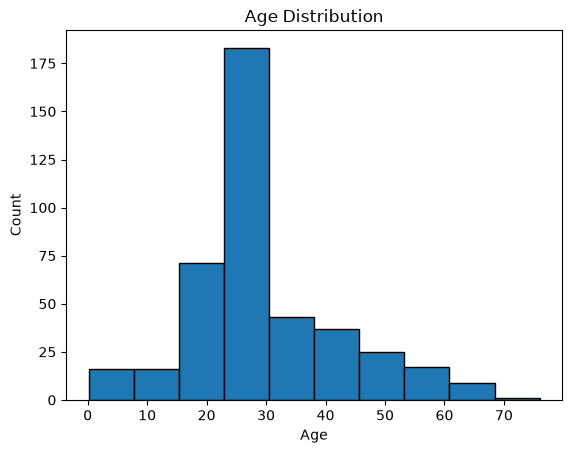

In [11]:
 
plt.hist(dc["Age"], edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [12]:
dc["Sex"] = dc["Sex"].map({
    "male":0,
    "female":1
})

In [13]:

dc["Embarked"] = dc["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})


In [19]:
x = dc[[
    "Pclass",
    "Sex",
    "Age",
]]

In [15]:

y = dc["Survived"]

In [20]:
 
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

# Prediction
prediction = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

print("Confusion Matrix")
print(confusion_matrix(y_test, prediction))

# Predict New Passenger
print("\nEnter Passenger Details")

pclass = int(input("Passenger Class (1/2/3): "))

sex = input("Sex (male/female): ")

if sex.lower() == "male":
    sex = 0
else:
    sex = 1

age = float(input("Age : "))

result = model.predict([[pclass, sex, age]])

if result[0] == 1:
    print("\nPassenger Survived")
else:
    print("\nPassenger Did Not Survive")

Accuracy : 1.0
Confusion Matrix
[[50  0]
 [ 0 34]]

Enter Passenger Details



Passenger Did Not Survive


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
